# Hieroglyph Transliteration → German Translation
## NLLB Fine-tuning

## 0. Environment Setup

In [ ]:
import os, sys
if 'torch' in sys.modules or 'transformers' in sys.modules:
    raise RuntimeError('Restart kernel first, then run this cell.')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
os.environ['CUDA_VISIBLE_DEVICES']    = '0'
os.environ['NCCL_P2P_DISABLE']        = '1'
os.environ['NCCL_IB_DISABLE']         = '1'
print('Environment ready.')

## 1. Install Dependencies

In [ ]:
import subprocess, sys

def run(cmd):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if r.returncode != 0:
        print(r.stderr[-2000:])
    return r.returncode

def is_installed():
    try:
        import numpy, torch, transformers, sacrebleu, evaluate
        print(f"Already installed. torch={torch.__version__}")
        return True
    except ImportError:
        return False

if not is_installed():
    print("Installing...")
    run("pip uninstall -y bitsandbytes torch torchvision torchaudio numpy scipy scikit-learn pandas")
    run("pip install -q --no-cache-dir 'numpy==1.26.4'")
    run("""pip install -q --no-cache-dir \
    torch==2.6.0 torchvision==0.21.0 torchaudio==2.6.0 \
    --index-url https://download.pytorch.org/whl/cu126""")
    run("""pip install -q --no-cache-dir \
    'scipy==1.11.4' 'scikit-learn==1.4.2' 'pandas==2.2.2'""")
    run("""pip install -q \
    'transformers==4.46.3' 'datasets==3.1.0' 'accelerate==1.1.1' \
    'sentencepiece==0.2.0' 'sacrebleu==2.4.3' 'evaluate==0.4.3' \
    'rouge_score==0.1.2' 'nltk==3.9.1' 'tqdm'""")
    print('Done. Restarting kernel...')
    import IPython
    IPython.Application.instance().kernel.do_shutdown(True)
else:
    print("Ready!")

## 2. Imports, Seeds, Device

In [2]:
import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

import re, gc, json, time, math, random, warnings, unicodedata
from contextlib import nullcontext
import functools
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
from collections import Counter
from datasets import Dataset as HFDataset, DatasetDict
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq, Seq2SeqTrainer, Seq2SeqTrainingArguments,
    EarlyStoppingCallback, set_seed,
)
import sacrebleu as _sacrebleu
import evaluate
import nltk
from nltk.translate.meteor_score import meteor_score
from nltk.translate.bleu_score import corpus_bleu as nltk_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from tqdm.auto import tqdm

nltk.download('punkt',     quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('omw-1.4',   quiet=True)

SEED = 42
set_seed(SEED); random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

if os.path.exists('/kaggle/working'):
    SAVE_DIR = '/kaggle/working/nllb-hiero-de-v4'
elif os.path.exists('/content'):
    SAVE_DIR = '/content/nllb-hiero-de-v4'
else:
    SAVE_DIR = './nllb-hiero-de-v4'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Save dir: {SAVE_DIR}')

Device : cuda:0
GPU    : Tesla P100-PCIE-16GB
VRAM   : 17.1 GB
Save dir: /kaggle/working/nllb-hiero-de-v4


## 3. Model


In [3]:
if torch.cuda.is_available():
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    USE_LARGE_MODEL = vram_gb >= 12.0
else:
    USE_LARGE_MODEL = False

MODEL_NAME = (
    'facebook/nllb-200-1.3B'
    if USE_LARGE_MODEL
    else 'facebook/nllb-200-distilled-600M'
)
print(f'Selected model : {MODEL_NAME}')
print(f'VRAM available : {vram_gb:.1f} GB' if torch.cuda.is_available() else 'CPU mode')

SRC_LANG = 'lao_Laoo'
TGT_LANG = 'deu_Latn'

Selected model : facebook/nllb-200-1.3B
VRAM available : 17.1 GB


## 4. Load and Clean Dataset

In [4]:
SRC_COL   = 'clean_transliteration'
TGT_COL   = 'clean_german'
DATA_PATH = '/kaggle/input/datasets/mo3azkhaled/nlp-dataset/dataset_cleaned.csv'

if not os.path.exists(DATA_PATH):
    candidates = [
        '/kaggle/input/test-dataset/dataset_cleaned.csv',
        '/kaggle/input/hieroglyphs-dataseet/dataset_cleaned.csv',
        './dataset_cleaned.csv',
    ]
    for c in candidates:
        if os.path.exists(c):
            DATA_PATH = c
            break
    else:
        raise FileNotFoundError('dataset_cleaned.csv not found.')

print(f'Loading: {DATA_PATH}')
df = pd.read_csv(DATA_PATH)
print(f'Raw rows : {len(df):,}')

df = df[[SRC_COL, TGT_COL]].dropna()
for col in [SRC_COL, TGT_COL]:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].str.replace(r'\s+', ' ', regex=True).str.strip()

df = df[df[SRC_COL].str.len() > 0]
df = df[df[TGT_COL].str.len() > 0]
df = df[df[SRC_COL].str.split().str.len().between(2, 80)]
df = df[df[TGT_COL].str.split().str.len().between(2, 80)]
df = df.drop_duplicates(subset=[SRC_COL, TGT_COL]).reset_index(drop=True)

print(f'After cleaning: {len(df):,} rows')
print(df[SRC_COL].str.split().str.len().describe().rename('src_words'))
print(df[TGT_COL].str.split().str.len().describe().rename('tgt_words'))

Loading: /kaggle/input/datasets/mo3azkhaled/nlp-dataset/dataset_cleaned.csv
Raw rows : 89,803
After cleaning: 86,621 rows
count    86621.000000
mean        10.078872
std          8.401540
min          2.000000
25%          5.000000
50%          8.000000
75%         12.000000
max         80.000000
Name: src_words, dtype: float64
count    86621.000000
mean        11.710601
std          9.422026
min          2.000000
25%          6.000000
50%          9.000000
75%         15.000000
max         80.000000
Name: tgt_words, dtype: float64


## 5.Split_Data

In [5]:
df_shuffled = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
n = len(df_shuffled)
n_train = int(n * 0.90); n_val = int(n * 0.05)

df_train = df_shuffled.iloc[:n_train].copy().reset_index(drop=True)
df_val   = df_shuffled.iloc[n_train:n_train+n_val].copy().reset_index(drop=True)
df_test  = df_shuffled.iloc[n_train+n_val:].copy().reset_index(drop=True)

print(f'Train: {len(df_train):,}  ({len(df_train)/n*100:.1f}%)')
print(f'Val  : {len(df_val):,}  ({len(df_val)/n*100:.1f}%)')
print(f'Test : {len(df_test):,}  ({len(df_test)/n*100:.1f}%)')

Train: 77,958  (90.0%)
Val  : 4,331  (5.0%)
Test : 4,332  (5.0%)


## 6. Enhanced Data Augmentation (Source-Only + Token Dropout)

In [6]:
import random as _rng

TRANSLIT_VARIANTS = {
    'ꜣ': ['ꜣ', 'A', '3'],
    'ꞽ': ['ꞽ', 'i', 'j'],
    'ꜥ': ['ꜥ', 'a', '['],
    'ḥ': ['ḥ', 'h', 'H'],
    'ḫ': ['ḫ', 'x'],
    'ẖ': ['ẖ', 'X', 'H'],
    'š': ['š', 'S', 'sh'],
    'ṯ': ['ṯ', 'T'],
    'ḏ': ['ḏ', 'D'],
    'ṣ': ['ṣ', 's'],
    'ḳ': ['ḳ', 'q', 'K'],
    'ʾ': ['ʾ', "'"],
    'ʿ': ['ʿ', '`'],
    'ī': ['ī', 'i'], 'ū': ['ū', 'u'],
    'ā': ['ā', 'a'], 'ō': ['ō', 'o'], 'ē': ['ē', 'e'],
}


def _apply_src_noise(text, p_substitute = 0.25,p_drop_diacritic= 0.10, p_char_op = 0.06, p_space_op = 0.08, p_token_drop = 0.10, p_word_swap = 0.08):
    out = []
    for ch in text:
        if ch in TRANSLIT_VARIANTS and _rng.random() < p_substitute:
            out.append(_rng.choice(TRANSLIT_VARIANTS[ch]))
        else:
            out.append(ch)
    text = ''.join(out)

    if _rng.random() < p_drop_diacritic:
        text = ''.join(
            ch for ch in unicodedata.normalize('NFKD', text)
            if not unicodedata.combining(ch)
        )

    if _rng.random() < p_char_op and len(text) > 4:
        chars = list(text)
        op = _rng.choice(['delete', 'swap', 'duplicate'])
        pool = [i for i, c in enumerate(chars) if not c.isspace()]
        if pool:
            i = _rng.choice(pool)
            if op == 'delete':
                del chars[i]
            elif op == 'swap' and i+1 < len(chars) and not chars[i+1].isspace():
                chars[i], chars[i+1] = chars[i+1], chars[i]
            elif op == 'duplicate':
                chars.insert(i, chars[i])
        text = ''.join(chars)

    if _rng.random() < p_space_op:
        words = text.split()
        if len(words) >= 3:
            if _rng.random() < 0.5:
                i = _rng.randrange(len(words) - 1)
                words[i] = words[i] + words[i+1]; del words[i+1]
            else:
                i = _rng.randrange(len(words))
                if len(words[i]) > 3:
                    cut = _rng.randint(2, len(words[i]) - 2)
                    words[i:i+1] = [words[i][:cut], words[i][cut:]]
            text = ' '.join(words)

    if _rng.random() < p_token_drop:
        words = text.split()
        if len(words) > 3:
            keep = [w for w in words if _rng.random() > 0.10]
            if len(keep) >= 2:
                text = ' '.join(keep)

    if _rng.random() < p_word_swap:
        words = text.split()
        if len(words) >= 4:
            i = _rng.randrange(len(words) - 1)
            words[i], words[i+1] = words[i+1], words[i]
            text = ' '.join(words)

    return re.sub(r'\s+', ' ', text).strip()


AUG_RATIO   = 0.70
N_AUG_PASSES = 2
_rng.seed(SEED)

orig_len = len(df_train)
n_aug    = int(orig_len * AUG_RATIO)

aug_src, aug_tgt = [], []
for _pass in range(N_AUG_PASSES):
    idx_list = _rng.sample(range(orig_len), n_aug)
    for idx in idx_list:
        s_orig = df_train[SRC_COL].iloc[idx]
        t_orig = df_train[TGT_COL].iloc[idx]
        s_new  = _apply_src_noise(s_orig)
        if s_new.strip() and s_new != s_orig:
            aug_src.append(s_new)
            aug_tgt.append(t_orig)

aug_df   = pd.DataFrame({SRC_COL: aug_src, TGT_COL: aug_tgt})
df_train = (pd.concat([df_train, aug_df], ignore_index=True)
              .sample(frac=1, random_state=SEED)
              .reset_index(drop=True))

print(f'Original train   : {orig_len:,}')
print(f'Augmented pairs  : {len(aug_src):,}  ({N_AUG_PASSES} passes × {n_aug:,} samples)')
print(f'Total train      : {len(df_train):,}')

ds_train = HFDataset.from_pandas(df_train.rename(columns={SRC_COL: 'src', TGT_COL: 'tgt'}))
ds_val   = HFDataset.from_pandas(df_val.rename(  columns={SRC_COL: 'src', TGT_COL: 'tgt'}))
ds_test  = HFDataset.from_pandas(df_test.rename( columns={SRC_COL: 'src', TGT_COL: 'tgt'}))
ds_dict  = DatasetDict({'train': ds_train, 'validation': ds_val, 'test': ds_test})
print(ds_dict)

Original train   : 77,958
Augmented pairs  : 67,315  (2 passes × 54,570 samples)
Total train      : 145,273
DatasetDict({
    train: Dataset({
        features: ['src', 'tgt'],
        num_rows: 145273
    })
    validation: Dataset({
        features: ['src', 'tgt'],
        num_rows: 4331
    })
    test: Dataset({
        features: ['src', 'tgt'],
        num_rows: 4332
    })
})


## 7. Tokenizer + Model + Smart Embedding Init

In [7]:
tokenizer = AutoTokenizer.from_pretrained( MODEL_NAME, src_lang=SRC_LANG, tgt_lang=TGT_LANG )
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

n_params = sum(p.numel() for p in model.parameters())
print(f'Model      : {MODEL_NAME}')
print(f'Params     : {n_params/1e6:.0f}M')
OLD_VOCAB  = len(tokenizer)

UNK_ID = tokenizer.unk_token_id
vocab  = tokenizer.get_vocab()

all_chars = Counter()
for t in df[SRC_COL]: all_chars.update(t)

missing = []
for ch, cnt in all_chars.most_common():
    if ch.isspace(): continue
    if UNK_ID in tokenizer(ch, add_special_tokens=False).input_ids:
        missing.append((ch, cnt))
    elif UNK_ID in tokenizer(f'a{ch}a', add_special_tokens=False).input_ids:
        missing.append((ch, cnt))

EGYPTOLOGICAL = [
    'ꜣ','ꞽ','ꜥ','ḥ','ḫ','ẖ','š','ṯ','ḏ','ṣ','ḳ','ʾ','ʿ',
    'i\u032f','u\u032f','ī','ū','ā','ō','ē',
]
tokens_to_add = set(ch for ch, _ in missing) | set(EGYPTOLOGICAL)
new_tokens    = [t for t in tokens_to_add if t not in vocab and f'▁{t}' not in vocab]

print(f'Missing chars : {len(missing)}')
print(f'New tokens    : {len(new_tokens)}')

if new_tokens:
    tokenizer.add_tokens(new_tokens)
    model.resize_token_embeddings(len(tokenizer))
    with torch.no_grad():
        emb = model.get_input_embeddings().weight
        mu  = emb[:OLD_VOCAB].mean(0)
        sig = emb[:OLD_VOCAB].std(0).mean().item() * 0.1
        for tid in range(OLD_VOCAB, len(tokenizer)):
            emb[tid] = mu + torch.randn_like(mu) * sig
        out = model.get_output_embeddings()
        if out is not None and out.weight is not emb:
            mu2 = out.weight[:OLD_VOCAB].mean(0)
            for tid in range(OLD_VOCAB, len(tokenizer)):
                out.weight[tid] = mu2 + torch.randn_like(mu2) * sig
    print(f'Added {len(new_tokens)} tokens → new vocab: {len(tokenizer):,}')

forced_bos_id = tokenizer.convert_tokens_to_ids(TGT_LANG)
assert forced_bos_id != tokenizer.unk_token_id
model.config.decoder_start_token_id         = forced_bos_id
model.config.forced_bos_token_id            = forced_bos_id
model.generation_config.forced_bos_token_id = forced_bos_id
print(f'forced_bos_token_id (deu_Latn): {forced_bos_id}')

probe = 'ḏ ḫ ḥ ꜣ ꞽ ꜥ ṯ ṣ ẖ ḳ i\u032f ʾ'
ids   = tokenizer.convert_tokens_to_ids(tokenizer.tokenize(probe))
n_unk = ids.count(UNK_ID)
print(f'UNK verification: {n_unk}/{len(ids)} →  {"OK" if n_unk == 0 else "FAIL"}')

tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/808 [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Model      : facebook/nllb-200-1.3B
Params     : 1371M
Missing chars : 10
New tokens    : 12


model.safetensors:   0%|          | 0.00/5.48G [00:00<?, ?B/s]

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Added 12 tokens → new vocab: 256,216
forced_bos_token_id (deu_Latn): 256042
UNK verification: 0/22 →  OK


## 8. Tokenization & Collator

In [8]:
src_lens = [len(tokenizer(s)['input_ids'])
            for s in df_train[SRC_COL].sample(min(2000, len(df_train)), random_state=SEED)]
tgt_lens = [len(tokenizer(t)['input_ids'])
            for t in df_train[TGT_COL].sample(min(2000, len(df_train)), random_state=SEED)]

MAX_SRC = 128
MAX_TGT = 128
print(f'MAX_SRC={MAX_SRC}  MAX_TGT={MAX_TGT}')

def preprocess(batch):
    mi = tokenizer(batch['src'], max_length=MAX_SRC, truncation=True, padding=False)
    lb = tokenizer(text_target=batch['tgt'], max_length=MAX_TGT, truncation=True, padding=False)
    mi['labels'] = lb['input_ids']
    return mi

tokenized = ds_dict.map(preprocess, batched=True, batch_size=512,
                        remove_columns=['src','tgt'], desc='Tokenizing')

collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer, model=model, padding='longest',
    pad_to_multiple_of=8 if torch.cuda.is_available() else None,
    label_pad_token_id=-100,
)
print(tokenized)

MAX_SRC=128  MAX_TGT=128


Tokenizing:   0%|          | 0/145273 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/4331 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/4332 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 145273
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 4331
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 4332
    })
})


## 9. Validation Metrics

In [9]:
metric_bleu = evaluate.load('sacrebleu')
metric_chrf = evaluate.load('chrf')


def postprocess(preds, labels):
    preds  = [p.strip() for p in preds]
    labels = [[l.strip()] for l in labels]
    return preds, labels


def compute_metrics(eval_preds):
    preds, labels = eval_preds
    if isinstance(preds, tuple): preds = preds[0]
    preds  = np.where(preds  != -100, preds,  tokenizer.pad_token_id)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    dp = tokenizer.batch_decode(preds,  skip_special_tokens=True)
    dl = tokenizer.batch_decode(labels, skip_special_tokens=True)
    dp, dl = postprocess(dp, dl)
    bleu = metric_bleu.compute(predictions=dp, references=dl)
    chrf = metric_chrf.compute(predictions=dp, references=dl)
    return {'bleu': round(bleu['score'], 3), 'chrf': round(chrf['score'], 3)}

## 10. Custom Trainer

In [10]:
from transformers import Seq2SeqTrainer

class FixedSeq2SeqTrainer(Seq2SeqTrainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        if 'decoder_input_ids' not in inputs and 'labels' in inputs:
            labels = inputs['labels']
            dec    = labels.new_zeros(labels.shape)
            dec[:, 1:] = labels[:, :-1].clone()
            dec[:, 0]  = model.config.decoder_start_token_id
            dec[dec == -100] = model.config.pad_token_id
            inputs['decoder_input_ids'] = dec
        return super().compute_loss(model, inputs, return_outputs=return_outputs,num_items_in_batch=num_items_in_batch)

## 11. Hyperparameters & Training Arguments


In [11]:
import warnings as _w
_w.filterwarnings('ignore', message=r'.*Trainer\.tokenizer.*')
_w.filterwarnings('ignore', message=r'.*`tokenizer` is deprecated.*')

if torch.cuda.is_available(): torch.cuda.empty_cache()
gc.collect()

BATCH_SIZE              = 4
EVAL_BATCH_SIZE         = 4
GRAD_ACCUM              = 8
EFFECTIVE_BATCH         = BATCH_SIZE * GRAD_ACCUM
EPOCHS                  = 10
LR                      = 2e-5
WARMUP_RATIO            = 0.10
WEIGHT_DECAY            = 0.01
LABEL_SMOOTHING         = 0.08
MAX_GRAD_NORM           = 1.0
EARLY_STOPPING_PATIENCE = 4

VAL_GENERATION_BEAMS    = 5
TEST_GENERATION_BEAMS   = 8
LENGTH_PENALTY          = 1.1
NO_REPEAT_NGRAM_SIZE    = 3
TEST_BATCH_SIZE         = 4

STEPS_PER_EPOCH = math.ceil(len(tokenized['train']) / EFFECTIVE_BATCH)
TOTAL_STEPS     = STEPS_PER_EPOCH * EPOCHS
WARMUP_STEPS    = max(int(TOTAL_STEPS * WARMUP_RATIO), 100)

print(f'Train samples  : {len(tokenized["train"]):,}')
print(f'Steps/epoch    : {STEPS_PER_EPOCH}')
print(f'Total steps    : {TOTAL_STEPS}')
print(f'Warmup steps   : {WARMUP_STEPS}')
print(f'Effective batch: {EFFECTIVE_BATCH}')
print(f'Val beams      : {VAL_GENERATION_BEAMS}')
print(f'Test beams     : {TEST_GENERATION_BEAMS}')

model.config.use_cache = False

training_args = Seq2SeqTrainingArguments(
    output_dir                    = SAVE_DIR,
    overwrite_output_dir          = True,
    num_train_epochs              = EPOCHS,
    per_device_train_batch_size   = BATCH_SIZE,
    per_device_eval_batch_size    = EVAL_BATCH_SIZE,
    gradient_accumulation_steps   = GRAD_ACCUM,
    learning_rate                 = LR,
    weight_decay                  = WEIGHT_DECAY,
    warmup_steps                  = WARMUP_STEPS,
    lr_scheduler_type             = 'cosine',
    optim                         = 'adafactor',
    label_smoothing_factor        = LABEL_SMOOTHING,
    max_grad_norm                 = MAX_GRAD_NORM,
    eval_strategy                 = 'epoch',
    save_strategy                 = 'epoch',
    save_total_limit              = 3,
    load_best_model_at_end        = True,
    metric_for_best_model         = 'bleu',
    greater_is_better             = True,
    logging_dir                   = os.path.join(SAVE_DIR, 'logs'),
    logging_strategy              = 'steps',
    logging_steps                 = 50,
    logging_first_step            = True,
    report_to                     = 'none',
    predict_with_generate         = True,
    generation_max_length         = MAX_TGT,
    generation_num_beams          = VAL_GENERATION_BEAMS,
    fp16                          = torch.cuda.is_available(),
    fp16_full_eval                = torch.cuda.is_available(),
    gradient_checkpointing        = True,
    gradient_checkpointing_kwargs = {'use_reentrant': True},
    group_by_length               = True,
    dataloader_num_workers        = 2,
    dataloader_pin_memory         = torch.cuda.is_available(),
    eval_accumulation_steps       = 4,
    seed                          = SEED,
    data_seed                     = SEED,
)

model.generation_config.num_beams            = VAL_GENERATION_BEAMS
model.generation_config.length_penalty       = LENGTH_PENALTY
model.generation_config.no_repeat_ngram_size = NO_REPEAT_NGRAM_SIZE
model.generation_config.early_stopping       = True
model.generation_config.max_length           = MAX_TGT

trainer = FixedSeq2SeqTrainer(
    model            = model,
    args             = training_args,
    train_dataset    = tokenized['train'],
    eval_dataset     = tokenized['validation'],
    processing_class = tokenizer,
    data_collator    = collator,
    compute_metrics  = compute_metrics,
    callbacks        = [EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
)
print('\nTrainer ready.')

Train samples  : 145,273
Steps/epoch    : 4540
Total steps    : 45400
Warmup steps   : 4540
Effective batch: 32
Val beams      : 5
Test beams     : 8

Trainer ready.


## 12. Phase 1 Training (Forward Model: Translit → German)

This trains the main forward model. After this we extract back-translation data.


In [12]:
_orig_load = torch.load
torch.load = functools.partial(_orig_load, weights_only=False)

if torch.cuda.is_available(): torch.cuda.empty_cache()
gc.collect()

t0 = time.time()
train_result = trainer.train(resume_from_checkpoint="/kaggle/input/notebooks/moaztest105/transliteration-german-v3-3/nllb-hiero-de-v4/checkpoint-45390")

training_time = time.time() - t0
print(f'\n{"="*60}')
print(f'Phase 1 done in {training_time/60:.1f} min')
print(f'{"="*60}')

trainer.save_model(os.path.join(SAVE_DIR, 'phase1_best'))
tokenizer.save_pretrained(os.path.join(SAVE_DIR, 'phase1_best'))
print(f'Best model saved → {SAVE_DIR}/phase1_best')

log_history = trainer.state.log_history
eval_logs   = [l for l in log_history if 'eval_bleu' in l]
if eval_logs:
    best = max(eval_logs, key=lambda x: x['eval_bleu'])
    print(f'\nBest val  BLEU : {best["eval_bleu"]:.2f}')
    print(f'Best val  chrF : {best["eval_chrf"]:.2f}')

There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].
Could not locate the best model at /kaggle/working/nllb-hiero-de-v4/checkpoint-45390/pytorch_model.bin, if you are running a distributed training on multiple nodes, you should activate `--save_on_each_node`.


Epoch,Training Loss,Validation Loss



Phase 1 done in 1.3 min
Best model saved → /kaggle/working/nllb-hiero-de-v4/phase1_best

Best val  BLEU : 39.32
Best val  chrF : 59.73


## 13. Phase 1 Learning Curves

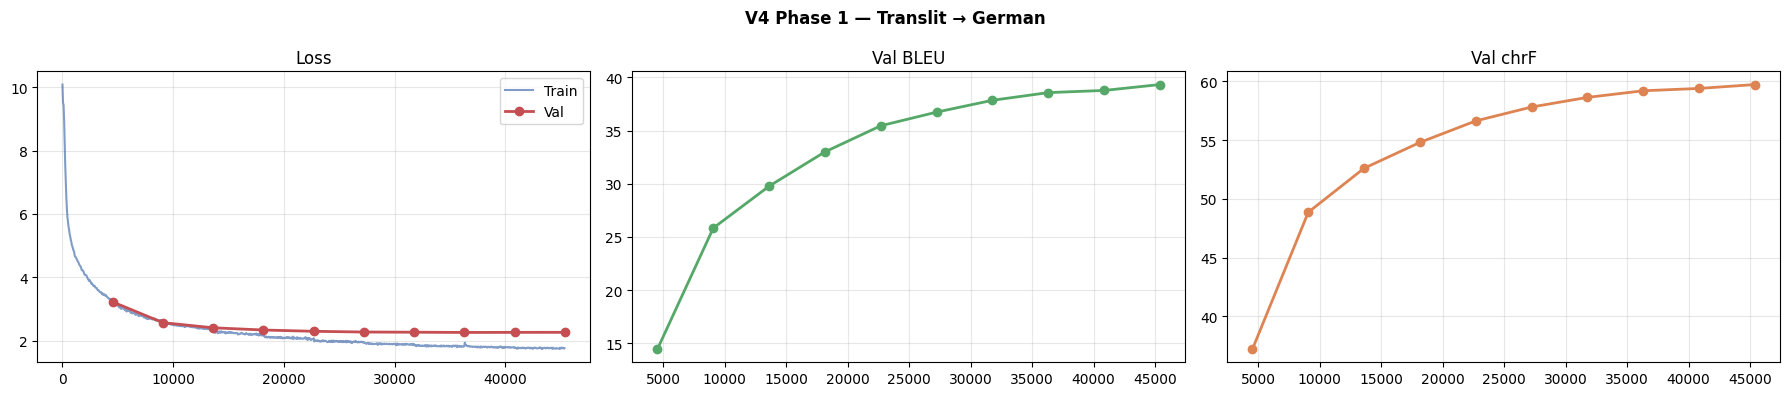

In [13]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
train_logs  = [l for l in log_history if 'loss' in l and 'eval_loss' not in l]
eval_logs   = [l for l in log_history if 'eval_loss' in l]

if eval_logs and train_logs:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    axes[0].plot([l['step'] for l in train_logs], [l['loss'] for l in train_logs],
                 '#4C72B0', lw=1.5, alpha=0.7, label='Train')
    axes[0].plot([l['step'] for l in eval_logs], [l['eval_loss'] for l in eval_logs],
                 '#C44E52', lw=2, marker='o', label='Val')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot([l['step'] for l in eval_logs], [l['eval_bleu'] for l in eval_logs],
                 '#55A868', lw=2, marker='o')
    axes[1].set_title('Val BLEU'); axes[1].grid(alpha=0.3)

    axes[2].plot([l['step'] for l in eval_logs], [l['eval_chrf'] for l in eval_logs],
                 '#DD8452', lw=2, marker='o')
    axes[2].set_title('Val chrF'); axes[2].grid(alpha=0.3)

    plt.suptitle('V4 Phase 1 — Translit → German', fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'phase1_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No eval logs to plot yet.')

## 14. Final Test Evaluation — Full Metric Suite

In [14]:
from sacrebleu import corpus_bleu as sb_corpus_bleu, corpus_chrf

if torch.cuda.is_available(): torch.cuda.empty_cache()
gc.collect()


train_src_set = set(df_train[SRC_COL].str.strip().tolist())

df_test_full = df_test.copy().reset_index(drop=True)
print(f"Total test rows (full)     : {len(df_test_full):,}")

leaked_mask   = df_test_full[SRC_COL].str.strip().isin(train_src_set)
n_leaked      = leaked_mask.sum()
n_clean       = (~leaked_mask).sum()

print(f"Leaked (src in train)      : {n_leaked:,}  ({n_leaked/len(df_test_full)*100:.1f}%)")
print(f"Clean (not in train)       : {n_clean:,}  ({n_clean/len(df_test_full)*100:.1f}%)")

if n_leaked > 0:
    print("\n Leakage detected — removing leaked rows from test set.")
    df_test_clean = df_test_full[~leaked_mask].reset_index(drop=True)
else:
    print("\n No leakage detected — using full test set.")
    df_test_clean = df_test_full.copy()

EVAL_N = 4000
if len(df_test_clean) >= EVAL_N:
    df_eval = df_test_clean.sample(EVAL_N, random_state=SEED).reset_index(drop=True)
    print(f"\n Sampled {EVAL_N:,} rows for evaluation.")
else:
    df_eval = df_test_clean.copy()
    print(f"\n Only {len(df_eval):,} clean rows available — using all of them.")

test_src = df_eval[SRC_COL].tolist()
test_ref = df_eval[TGT_COL].tolist()

INFERENCE_CHECKPOINT = "/kaggle/input/notebooks/moaztest105/transliteration-german-v3-3/nllb-hiero-de-v4/checkpoint-45390"

print(f"\nLoading inference model from:\n  {INFERENCE_CHECKPOINT}")

inference_tokenizer = AutoTokenizer.from_pretrained(
    INFERENCE_CHECKPOINT, src_lang=SRC_LANG, tgt_lang=TGT_LANG,
)
model_inf = AutoModelForSeq2SeqLM.from_pretrained(INFERENCE_CHECKPOINT)
inference_device = device
model_inf = model_inf.to(inference_device).eval()
model_inf.config.use_cache = True

forced_bos_inf = inference_tokenizer.convert_tokens_to_ids(TGT_LANG)
assert forced_bos_inf != inference_tokenizer.unk_token_id, "TGT_LANG token not in tokenizer!"

print(f"forced_bos_token_id ({TGT_LANG}): {forced_bos_inf}")
print(f"Inference device   : {inference_device}")
print(f"Inference precision: fp32 (no autocast)")
print(f"Model params       : {sum(p.numel() for p in model_inf.parameters())/1e6:.0f}M")


def maybe_cast():
    return nullcontext()


def translate_batch(texts, batch_size=TEST_BATCH_SIZE, num_beams=TEST_GENERATION_BEAMS, max_new_tokens=None):
    if max_new_tokens is None: max_new_tokens = MAX_TGT
    results = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Translating"):
        batch  = texts[i:i+batch_size]
        inputs = inference_tokenizer(
            batch, return_tensors="pt", padding=True,
            truncation=True, max_length=MAX_SRC,
        ).to(inference_device)
        with torch.inference_mode(), maybe_cast():
            out = model_inf.generate(
                **inputs,
                forced_bos_token_id  = forced_bos_inf,
                num_beams            = num_beams,
                max_new_tokens       = max_new_tokens,
                length_penalty       = LENGTH_PENALTY,
                no_repeat_ngram_size = NO_REPEAT_NGRAM_SIZE,
                early_stopping       = True,
                do_sample            = False,
            )
        results.extend(inference_tokenizer.batch_decode(out, skip_special_tokens=True))
    return results


print(f"\nTranslating {len(test_src):,} sentences "
      f"(beam={TEST_GENERATION_BEAMS}, fp32, device={inference_device})...")
test_hyp = translate_batch(test_src)
print(f" Translation finished. {len(test_hyp):,} hypotheses.")

preds_df = pd.DataFrame({"src": test_src, "ref": test_ref, "hyp": test_hyp})
preds_path = os.path.join(SAVE_DIR, "test_predictions_clean.csv")
preds_df.to_csv(preds_path, index=False)
print(f" Predictions saved -> {preds_path}")

sb_bleu  = sb_corpus_bleu(test_hyp, [test_ref])
sb_chrf  = corpus_chrf(test_hyp, [test_ref])
sb_chrf2 = corpus_chrf(test_hyp, [test_ref], word_order=2)

smooth   = SmoothingFunction().method3
refs_b   = [[r.split()] for r in test_ref]
hyps_b   = [h.split()   for h in test_hyp]

nltk_b4 = nltk_bleu(refs_b, hyps_b, weights=(.25,.25,.25,.25), smoothing_function=smooth)*100

met_scores = []
for r, h in zip(test_ref, test_hyp):
    try:    met_scores.append(meteor_score([r.split()], h.split()))
    except: met_scores.append(0.0)
meteor = sum(met_scores)/max(len(met_scores),1)*100

rscorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
rouge_l = sum(rscorer.score(r,h)["rougeL"].fmeasure
              for r,h in zip(test_ref,test_hyp))/max(len(test_ref),1)*100

results_clean = {
    "sacreBLEU" : round(sb_bleu.score, 3),
    "chrF"      : round(sb_chrf.score, 3),
    "chrF++"    : round(sb_chrf2.score, 3),
    "NLTK_BLEU-4": round(nltk_b4, 3),
    "METEOR"    : round(meteor, 3),
    "Rouge-L"   : round(rouge_l, 3),
}

with open(os.path.join(SAVE_DIR, "test_results_clean.json"), "w") as f:
    json.dump(results_clean, f, indent=2)

print("\n" + "="*68)
print(f"  CLEAN TEST RESULTS — Hieroglyph Translit → German")
print(f"  (leakage removed, fp32 inference on {inference_device})")
print("="*68)
W = max(len(k) for k in results_clean) + 2
for k, v in results_clean.items():
    print(f"  {k:<{W}}: {v}")
print("="*68)
print(f"\n Sentences evaluated       : {len(test_src):,}")
print(f"  Leaked rows removed       : {n_leaked:,}  ({n_leaked/len(df_test_full)*100:.1f}%)")
print(f"  Clean rows available      : {n_clean:,}")
print("="*68)

Total test rows (full)     : 4,332
Leaked (src in train)      : 299  (6.9%)
Clean (not in train)       : 4,033  (93.1%)

 Leakage detected — removing leaked rows from test set.

 Sampled 4,000 rows for evaluation.

Loading inference model from:
  /kaggle/input/notebooks/moaztest105/transliteration-german-v3-3/nllb-hiero-de-v4/checkpoint-45390


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

forced_bos_token_id (deu_Latn): 256042
Inference device   : cuda:0
Inference precision: fp32 (no autocast)
Model params       : 1371M

Translating 4,000 sentences (beam=8, fp32, device=cuda:0)...


Translating:   0%|          | 0/1000 [00:00<?, ?it/s]

 Translation finished. 4,000 hypotheses.
 Predictions saved -> /kaggle/working/nllb-hiero-de-v4/test_predictions_clean.csv

  CLEAN TEST RESULTS — Hieroglyph Translit → German
  (leakage removed, fp32 inference on cuda:0)
  sacreBLEU    : 38.985
  chrF         : 59.161
  chrF++       : 57.491
  NLTK_BLEU-4  : 33.687
  METEOR       : 49.968
  Rouge-L      : 59.349

 Sentences evaluated       : 4,000
  Leaked rows removed       : 299  (6.9%)
  Clean rows available      : 4,033


## 15. Translation Examples

In [15]:
print('\n── Translation Examples (Clean / No Leakage) ──────────')
train_targets = set(df_train[TGT_COL])
train_src_set = set(df_train[SRC_COL].str.strip())

clean_idx = [
    i for i in range(len(test_ref))
    if test_ref[i] not in train_targets
    and test_src[i].strip() not in train_src_set
]

print(f'Total clean available: {len(clean_idx)}')

sample_idx = random.sample(clean_idx, min(100, len(clean_idx)))

for i in sample_idx:
    print(f'SRC : {test_src[i]}')
    print(f'REF : {test_ref[i]}')
    print(f'HYP : {test_hyp[i]}')
    print()


── Translation Examples (Clean / No Leakage) ──────────
Total clean available: 3208
SRC : nꜣ jw tw r jni̯w w jw sn r ḥꜣt nꜣj rmṯ
REF : Soll man sie bringen, indem sie vor diesen Leuten sind?
HYP : Die, die man bringen wird, sie sind an der Spitze dieser Leute.

SRC : m sḫm nb f Wbnj psd m wḏꜣtj f sḥḏ
REF : durch die Macht seines Herrn, des 'Glänzenden', der mit seinen beiden Udjat-Augen leuchtet der. erhellt.!
HYP : durch die Macht seines Herrn, des Aufwärters, der durch sein Udjat-Auge leuchtet, der leuchtet

SRC : m jr qnqn
REF : Schlage nicht
HYP : Tritt nicht in den Schlagabtausch!

SRC : jmm ḥꜣw n tjnplrʾ
REF : Laß Tüchtigkeit wachsen!
HYP : Gib einen Zuwachs an die tjn-Pflanzen!

SRC : Rꜥw ḥqꜣ ꜣḫtj ḥꜥi̯ m ꜣḫt
REF : Re-heqa-achti, der im Horizont jubelt
HYP : Re-heqa-achti, der im Horizont jubelt

SRC : jnk sꜥnḫ mtn
REF : Ich bin einer, der am Leben erhält und --- zuweist
HYP : Ich bin einer, der eure Wege belebt.

SRC : mḥrt ḫprt r jꜣt m ḫsfw mwt
REF : Krankheit, die entstanden 

## 16. Inference Helper

In [16]:
def translate(text: str, num_beams: int = 8) -> str:
    inputs = inference_tokenizer(
        text, return_tensors='pt', truncation=True, max_length=MAX_SRC
    ).to(inference_device)
    with torch.inference_mode(), maybe_cast():
        out = model_inf.generate(
            **inputs,
            forced_bos_token_id  = forced_bos_inf,
            num_beams            = num_beams,
            max_new_tokens       = MAX_TGT,
            length_penalty       = LENGTH_PENALTY,
            no_repeat_ngram_size = NO_REPEAT_NGRAM_SIZE,
            early_stopping       = True,
            do_sample            = False,
        )
    return inference_tokenizer.decode(out[0], skip_special_tokens=True)

example = 'ḫꜣ m tʾ ḥnqt kꜣ ꜣpd n ꞽmꜣḫ ꞽmꞽ rʾ šnꜥ ꞽmn m ḥꜣt mꜣꜥ ḫrw'
print(f'INPUT : {example}')
print(f'OUTPUT: {translate(example)}')

INPUT : ḫꜣ m tʾ ḥnqt kꜣ ꜣpd n ꞽmꜣḫ ꞽmꞽ rʾ šnꜥ ꞽmn m ḥꜣt mꜣꜥ ḫrw
OUTPUT: Tausend an Brot, Bier, Rindern und Geflügel für den Versorgten, den Vorsteher des Magazins, Amenemhet, den Gerechtfertigten.
